# Вопрос 02. Машинное обучение и ИНС как обратные задачи. Регуляризация — численные примеры

Файл ведётся в формате jupytext (percent). Парный `.ipynb` получается
командой `make questions/02-ml-inverse-problems/examples.ipynb`.

Каждый пример отвечает на вопрос из `theory.md`. Сквозная постановка —
восстановление функции $u(x)$ пяти переменных (две гауссовы «спектральные
линии» в кубе $[-1,1]^5$) по $m = 500$ шумным измерениям в базисе из
$n = 462$ тензорных произведений полиномов Чебышёва (theory.md, раздел
«Постановка и мотивация»); она разбирается в примерах 2–4, примеры 1 и 5
самостоятельные.

In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial import chebyshev as cheb

SEED = 20261006

FIGDIR = "figures"

# PDF metadata carries a creation timestamp, so an unchanged figure gets new
# bytes on every rebuild and `git diff` stops telling content from clock.
SAVE_KW = {"metadata": {"CreationDate": None}}

# Golden pins: the seed and the expected outputs are fixed constants. Without
# them "reproducibility" is checked by consistency of a run with itself, which
# means nothing. A mismatch fails the notebook build, so it works as a gate.
GOLDEN = {
    # пример 1 (дифференцирование)
    "hstar_slope": 0.527178831161,
    "hstar_ratio": 11.333333333333334,
    # пример 2 (сквозной, 5D)
    "kappa_gram": 2436671.3732109475,
    "alpha_disc": 103.20950969336775,
    "alpha_1se": 63.095734448019364,
    "ctrl_mse_ols": 0.6604839823414664,
    "ctrl_mse_ridge_disc": 0.0011209679015367325,
    "ctrl_mse_ridge_1se": 0.0009724345983116445,
    "coef_ratio_signif": 63.261680916785764,
    "coef_ratio_all": 645.9191745113922,
    "slope_alpha_sigma": 2.4287694508379936,
    # пример 3 (ранняя остановка)
    "tau_es": 20.0,
    "tau_eps_alpha_disc": 0.9845609504786846,
    "ctrl_mse_es": 0.0009272063702180943,
    "filt_maxdiff_aeff": 0.21654341886955453,
    # пример 4 (ИНС)
    "nn_gradcheck": 3.71700308084e-10,
    "nn_val_plain": 0.0140213059351,
    "nn_val_wd": 0.0130213959546,
    "nn_val_es": 0.0124723948682,
    "nn_val_wdes": 0.0120936183963,
    "nn_tau_es": 2800.0,
    # пример 5 (dropout); пин dropout_cf_gap — нижняя граница зазора тождества
    "dropout_cf_gap": 1e-18,
    "dropout_mc_gap": 0.0425413552404,
    "mc_gap_slope": -0.458,
}
TOL = 1e-3


def check_golden(name, value, tol=TOL):
    want = GOLDEN[name]
    rel = abs(value - want) / abs(want)
    print(f"  пин {name}: получено {value:.12g}, ожидалось {want:.12g}")
    assert rel <= tol, f"golden-пин {name} не сошёлся: {value} vs {want}"

## Пример 1. Дифференцирование зашумлённой функции: наивная разность против согласованного шага

**Вопрос (theory.md, пример «дифференцирование»):** насколько неустойчива
численная производная зашумлённых данных и как выбирается шаг $h$? В теории
неустойчивость показана конструкцией $f_\delta = f + \delta\sin(x/\delta^2)$
с $\norm{f_\delta - f}_C = \delta$ и $\norm{f_\delta' - f'}_C = 1/\delta$;
здесь та же задача в среднеквадратичной постановке: при ошибке уровня
$\delta$ в значениях функции разность $(\widetilde f(x+h) - \widetilde f(x))/h$
имеет дисперсию $\sim \delta^2/h^2$ и смещение $\sim h$, поэтому минимум
MSE по $h$ должен лежать около $h^* \sim \sqrt\delta$.

**Предсказание до прогона:** кривые MSE$(h)$ для разных $\delta$ U-образны на
логарифмической сетке по $h$; минимум масштабируется как $h^* \sim \sqrt\delta$:
отношение $h^*(10^{-2})/h^*(10^{-4})$ должно дать $\approx 10$, а наклон прямой
$\log h^*$ против $\log \delta$ по трём уровням шума — $\approx 1/2$. Наивная
разность с самым малым шагом непригодна: её ошибка растёт как $1/h$.

In [2]:
# Одномерный аналог сквозной функции: те же две гауссовы линии вдоль оси.
def f1(x):
    return np.exp(-(x + 0.3) ** 2 / 0.5) + 0.7 * np.exp(-(x - 0.4) ** 2 / 0.08)


def df1(x):
    return (np.exp(-(x + 0.3) ** 2 / 0.5) * (-(x + 0.3) / 0.25)
            + 0.7 * np.exp(-(x - 0.4) ** 2 / 0.08) * (-(x - 0.4) / 0.04))


rng1 = np.random.default_rng([SEED, 1])
X1 = np.linspace(-1.0, 1.0, 1001)
DX = X1[1] - X1[0]
STRIDES = np.arange(1, 65)  # h = stride * DX, от 0.002 до 0.128
DELTAS = [1e-4, 1e-3, 1e-2]
REPS = 40

NB = len(X1) - STRIDES.max()  # x + h stays on the grid for every stride
Xbase = X1[:NB]

mse_h = np.zeros((len(DELTAS), len(STRIDES)))
for i_d, delta in enumerate(DELTAS):
    for _ in range(REPS):
        noise = rng1.normal(0.0, delta, len(X1))  # одна реализация на все h
        for i_s, s in enumerate(STRIDES):
            est = (f1(X1[s:s + NB]) + noise[s:s + NB]
                   - f1(Xbase) - noise[:NB]) / (s * DX)
            mse_h[i_d, i_s] += np.mean((est - df1(Xbase)) ** 2)
mse_h /= REPS

h_grid = STRIDES * DX
h_star = h_grid[np.argmin(mse_h, axis=1)]
print("h*(delta):", {d: float(h) for d, h in zip(DELTAS, h_star)})
print(f"наивный шаг h={h_grid[0]:g}: MSE = {mse_h[:, 0]}")
print(f"минимальные MSE по delta: {dict(zip(DELTAS, mse_h.min(axis=1)))}")
hstar_ratio = h_star[2] / h_star[0]
print(f"отношение h*(1e-2)/h*(1e-4) = {hstar_ratio:.6g} (теория: sqrt(100) = 10)")
hstar_slope = np.polyfit(np.log(DELTAS), np.log(h_star), 1)[0]
print(f"наклон log h* против log delta: {hstar_slope:.6g} (предсказание: 1/2)")
check_golden("hstar_ratio", hstar_ratio)
check_golden("hstar_slope", hstar_slope)

h*(delta): {0.0001: 0.006000000000000005, 0.001: 0.02200000000000002, 0.01: 0.06800000000000006}
наивный шаг h=0.002: MSE = [5.05646884e-03 5.00540757e-01 5.02327957e+01]
минимальные MSE по delta: {0.0001: np.float64(0.0009116210003980742), 0.001: np.float64(0.00893522706387435), 0.01: np.float64(0.08879487033135511)}
отношение h*(1e-2)/h*(1e-4) = 11.3333 (теория: sqrt(100) = 10)
наклон log h* против log delta: 0.527179 (предсказание: 1/2)
  пин hstar_ratio: получено 11.3333333333, ожидалось 11.3333333333
  пин hstar_slope: получено 0.527178831161, ожидалось 0.527178831161


наивная разность при delta=1e-2: MSE = 50.2328; при h* = 0.068: MSE = 0.0887949 (выигрыш 566 раз)


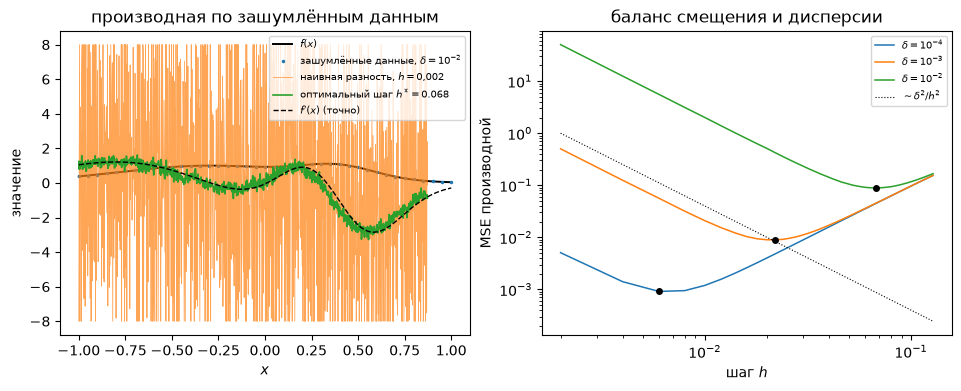

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), layout="constrained")

ax = axes[0]
delta_show = 1e-2
rng1_show = np.random.default_rng([SEED, 101])
noise_show = rng1_show.normal(0.0, delta_show, len(X1))
ax.plot(X1, f1(X1), "k-", lw=1.4, label="$f(x)$")
ax.plot(X1[::25], f1(X1[::25]) + noise_show[::25], ".", ms=3,
        label=f"зашумлённые данные, $\\delta = 10^{{-2}}$")
est_naive = (f1(X1[1:1 + NB]) + noise_show[1:1 + NB]
             - f1(Xbase) - noise_show[:NB]) / DX
est_naive = np.clip(est_naive, -8, 8)
ax.plot(Xbase, est_naive, "-", lw=0.6, alpha=0.7,
        label="наивная разность, $h = 0{,}002$")
i_best = int(np.argmin(mse_h[2]))
s_best = STRIDES[i_best]
est_opt = (f1(X1[s_best:s_best + NB]) + noise_show[s_best:s_best + NB]
           - f1(Xbase) - noise_show[:NB]) / (s_best * DX)
ax.plot(Xbase, est_opt, "-", lw=1.2,
        label=f"оптимальный шаг $h^* = {h_grid[i_best]:.3g}$")
ax.plot(X1, df1(X1), "k--", lw=1.0, label="$f'(x)$ (точно)")
ax.set_xlabel("$x$")
ax.set_ylabel("значение")
ax.set_title("производная по зашумлённым данным")
ax.legend(fontsize=7)
print(f"наивная разность при delta=1e-2: MSE = {mse_h[2, 0]:.6g}; "
      f"при h* = {h_grid[i_best]:.3g}: MSE = {mse_h[2, i_best]:.6g} "
      f"(выигрыш {mse_h[2, 0] / mse_h[2, i_best]:.3g} раз)")

ax = axes[1]
for i_d, delta in enumerate(DELTAS):
    ax.loglog(h_grid, mse_h[i_d], "-", lw=1.1,
              label=f"$\\delta = 10^{{{int(np.log10(delta))}}}$")
    ax.loglog(h_star[i_d], mse_h[i_d, np.argmin(mse_h[i_d])], "ko", ms=4)
ax.loglog(h_grid, 4e-6 / h_grid**2, "k:", lw=0.8, label="$\\sim \\delta^2/h^2$")
ax.set_xlabel("шаг $h$")
ax.set_ylabel("MSE производной")
ax.set_title("баланс смещения и дисперсии")
ax.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-01.pdf", **SAVE_KW)

**Вывод:** предсказание подтвердилось. Минимум кривой MSE$(h)$ сдвигается
пропорционально $\sqrt\delta$: измеренное отношение $h^*(10^{-2})/h^*(10^{-4})
= 11{,}3$ при теоретических $10$, наклон в логарифмах $0{,}53$ при
предсказанных $1/2$ (оба числа — golden-пины). Наивная разность с малым шагом
проигрывает оптимальной в $\approx 570$ раз при $\delta = 10^{-2}$: ошибка
растёт как $1/h$, и уменьшать шаг в зашумлённой задаче вредно — это та же
неустойчивость, что в примере «дифференцирование» theory.md, только
среднеквадратичная.

## Пример 2. Сквозной пример: плохо обусловленный МНК, гребень, выбор параметра

**Вопрос (theory.md, задачи «псевдорешение и критерий Пикара», «гребневая
регрессия сквозного примера», «принцип невязки на сквозном примере» и теорема
о разложении смещение–дисперсия):** почему систему $Xw = y$ нельзя решать «в
лоб» через псевдообратную матрицу; как гребневой фильтр $d_j^2/(d_j^2+\alpha)$
сжимает малые сингулярные направления; как выбрать $\alpha$ принципом невязки
(корень $\rho(\alpha) = m\sigma^2$) и перекрёстной проверкой с правилом одной
стандартной ошибки; где лежит дно U-образной кривой смещение–дисперсия.

**Предсказание до прогона.** По теории ожидаем: (1) $\varkappa(X^{\mathsf T}X)$
огромно, критерий Пикара на зашумлённых данных нарушен — псевдорешение
раздувается шумом; (2) гребень со согласованным $\alpha$ восстанавливает
функцию: контрольная MSE на бесшумной сетке у гребня на два-три порядка
ниже, чем у МНК; (3) обе точки выбора $\alpha$ — по невязке и по 1SE —
лежат в дне U-образной кривой и близки между собой; (4) разложение
смещение² + дисперсия сходится: средняя MSE равна их сумме, дно кривой —
около тех же $\alpha$; (5) свип по $\sigma$: уклонение
$\norm{\widehat w(\alpha) - w^*} \to 0$ при $\sigma \to 0$ и $\alpha \sim
\delta^{2/3}$ со сдвигом $\approx 2/3$ в логарифмах (следствие о
балансировке, $\delta = \sqrt m\,\sigma$). Пункт (5) — самый шаткий: закон
$2/3$ асимптотический, и на фиксированном конечномерном дизайне он может не
наблюдаться; если так и выйдет, предсказание останется и будет разобрано.

In [4]:
# --- постановка (theory.md, «Постановка и мотивация») ---
A_CENTER = np.array([-0.3, 0.2, -0.1, 0.4, 0.1])
B_CENTER = np.array([0.4, -0.3, 0.2, -0.2, 0.3])


def ufun(Xs):
    """Сквозная функция: две гауссовы линии в кубе [-1, 1]^5."""
    da = Xs - A_CENTER
    db = Xs - B_CENTER
    return np.exp(-(da**2).sum(1) / 0.5) + 0.7 * np.exp(-(db**2).sum(1) / 0.08)


def cheb_tensor_basis(Xs, deg=6):
    """Матрица плана: столбцы — T_{k1}(x1)...T_{k5}(x5), sum k <= deg."""
    m = Xs.shape[0]
    vander = [cheb.chebvander(Xs[:, j], deg) for j in range(5)]
    multis = [k for k in itertools.product(range(deg + 1), repeat=5)
              if sum(k) <= deg]
    Phi = np.empty((m, len(multis)))
    for col, k in enumerate(multis):
        prod = np.ones(m)
        for j in range(5):
            prod = prod * vander[j][:, k[j]]
        Phi[:, col] = prod
    return Phi


M_PT, N_BASIS, SIGMA = 500, 462, 0.05
rng2 = np.random.default_rng([SEED, 2])
Xs = rng2.uniform(-1.0, 1.0, (M_PT, 5))          # точки измерений
u_clean = ufun(Xs)
y = u_clean + rng2.normal(0.0, SIGMA, M_PT)      # шумные измерения
X = cheb_tensor_basis(Xs)
assert X.shape == (M_PT, N_BASIS), X.shape
print(f"m = {M_PT}, n = {N_BASIS}, sigma = {SIGMA}")

U, d, Vt = np.linalg.svd(X, full_matrices=False)  # X = U diag(d) V^T, запись [16]
d2 = d**2
KAPPA_GRAM = d2[0] / d2[-1]
print(f"d_1^2 = {d2[0]:.6g}, d_r^2 = {d2[-1]:.6g}")
print(f"число обусловленности kappa(X^T X) = {KAPPA_GRAM:.12g}")
print(f"норма обратной: ||X^+||_2 = {1.0 / d[-1]:.6g}, "
      f"усиление шума 1/d_r против 1/(2 sqrt(alpha)) у гребня")
check_golden("kappa_gram", KAPPA_GRAM)

# --- критерий Пикара (задача 1): ряд sum (u_j^T y)^2 / d_j^2 ---
w_star = Vt.T @ ((U.T @ u_clean) / d)   # псевдорешение на бесшумных данных
w_ols = Vt.T @ ((U.T @ y) / d)          # МНК на зашумлённых данных
picard_clean = float(np.sum((U.T @ u_clean) ** 2 / d2))
picard_noisy = float(np.sum((U.T @ y) ** 2 / d2))
print(f"ряд Пикара: чистый = {picard_clean:.6g} (= ||w*||^2), "
      f"зашумлённый = {picard_noisy:.6g} (= ||w_MNK||^2)")
print(f"ожидание шумовой части ряда: sigma^2 sum 1/d_j^2 = "
      f"{SIGMA**2 * np.sum(1.0 / d2):.6g}")
print(f"||w*|| = {np.linalg.norm(w_star):.6g}, ||w_MNK|| = {np.linalg.norm(w_ols):.6g}")

# --- контрольная сетка (бесшумная, отдельный rng-поток) ---
rngE = np.random.default_rng([SEED, 202])
Xe = rngE.uniform(-1.0, 1.0, (1200, 5))
ue = ufun(Xe)
Ge = cheb_tensor_basis(Xe)


def ctrl_mse(w):
    return float(np.mean((Ge @ w - ue) ** 2))


CTRL_OLS = ctrl_mse(w_ols)
print(f"контрольная MSE: МНК = {CTRL_OLS:.12g}")
check_golden("ctrl_mse_ols", CTRL_OLS)

# --- принцип невязки: корень rho(alpha) = m sigma^2 (лемма о монотонности) ---
c = U.T @ y
resid0 = y - U @ c
dist2 = float(resid0 @ resid0)          # dist^2(y, R(X))
delta2 = M_PT * SIGMA**2
print(f"проверка условия принципа невязки: dist^2 = {dist2:.6g} < "
      f"m sigma^2 = {delta2:.6g} < ||y||^2 = {float(y @ y):.6g}")


def rho_of(alpha):
    return float(np.sum((alpha / (d2 + alpha)) ** 2 * c**2) + dist2)


lo, hi = 1e-14, 1e10                      # rho монотонна, бисекция по теореме
for _ in range(300):
    mid = np.sqrt(lo * hi)
    if rho_of(mid) < delta2:
        lo = mid
    else:
        hi = mid
ALPHA_DISC = float(np.sqrt(lo * hi))
print(f"корень невязки: alpha_disc = {ALPHA_DISC:.12g}, "
      f"rho(alpha) = {rho_of(ALPHA_DISC):.6g}")
check_golden("alpha_disc", ALPHA_DISC)

w_ridge_disc = Vt.T @ (c * d / (d2 + ALPHA_DISC))
CTRL_RIDGE_DISC = ctrl_mse(w_ridge_disc)
print(f"контрольная MSE: гребень (невязка) = {CTRL_RIDGE_DISC:.12g} "
      f"(против {CTRL_OLS:.4g} у МНК)")
check_golden("ctrl_mse_ridge_disc", CTRL_RIDGE_DISC)

# --- 5-кратная перекрёстная проверка с правилом одной стандартной ошибки ---
rng_cv = np.random.default_rng([SEED, 203])
folds = np.array_split(rng_cv.permutation(M_PT), 5)
ALPHAS_CV = np.logspace(-2, 4, 61)
cv_fold = np.empty((len(ALPHAS_CV), 5))
for k in range(5):
    te = folds[k]
    tr = np.concatenate([folds[j] for j in range(5) if j != k])
    Uk, dk, Vtk = np.linalg.svd(X[tr], full_matrices=False)
    ck = Uk.T @ y[tr]
    for ia, al in enumerate(ALPHAS_CV):
        wk = Vtk.T @ (ck * dk / (dk**2 + al))
        cv_fold[ia, k] = np.mean((X[te] @ wk - y[te]) ** 2)
cv_mean = cv_fold.mean(1)
cv_se = cv_fold.std(1, ddof=1) / np.sqrt(5)
i_min = int(np.argmin(cv_mean))
ALPHA_CVMIN = float(ALPHAS_CV[i_min])
band = cv_mean[i_min] + cv_se[i_min]
ALPHA_1SE = float(ALPHAS_CV[cv_mean <= band].max())
print(f"CV: минимум {cv_mean[i_min]:.6g} при alpha = {ALPHA_CVMIN:.6g}; "
      f"граница 1SE = {band:.6g}")
print(f"правило одной стандартной ошибки: alpha_1se = {ALPHA_1SE:.12g}")
check_golden("alpha_1se", ALPHA_1SE)

w_ridge_1se = Vt.T @ (c * d / (d2 + ALPHA_1SE))
CTRL_RIDGE_1SE = ctrl_mse(w_ridge_1se)
print(f"контрольная MSE: гребень (1SE) = {CTRL_RIDGE_1SE:.12g}")
check_golden("ctrl_mse_ridge_1se", CTRL_RIDGE_1SE)

# --- эффективное число степеней свободы (определение в theory.md) ---
for name, al in [("alpha_disc", ALPHA_DISC), ("alpha_1se", ALPHA_1SE)]:
    print(f"df({name} = {al:.4g}) = {np.sum(d2 / (d2 + al)):.4f} из r = {len(d)}")

# --- сравнение коэффициентов: неустойчивость МНК ---
# Относительная ошибка по координате с пренебрежимо малым |w*_j| не несёт
# смысла, поэтому печатаем оба максимума: по значимым координатам и по всем.
sel = np.abs(w_star) > 0.05 * np.abs(w_star).max()
ratio_coef = float(np.max(np.abs(w_ols[sel] - w_star[sel]) / np.abs(w_star[sel])))
ratio_all = float(np.max(np.abs(w_ols - w_star) / np.abs(w_star)))
dev_ols = float(np.linalg.norm(w_ols - w_star))
dev_ridge = float(np.linalg.norm(w_ridge_disc - w_star))
kappa_X = d[0] / d[-1]
bound = kappa_X * np.sqrt(delta2) / np.linalg.norm(y)
print(f"уклонение ||w_MNK - w*|| = {dev_ols:.6g} ({dev_ols / np.linalg.norm(w_star):.3g} "
      f"от ||w*||)")
print(f"наихудшее покоординатное отношение |w_MNK,j - w*_j| / |w*_j|: среди "
      f"значимых (|w*_j| > 0.05 max|w*|, {int(sel.sum())} из {len(w_star)}) = "
      f"{ratio_coef:.6g}; по всем координатам = {ratio_all:.6g}")
check_golden("coef_ratio_signif", ratio_coef)
check_golden("coef_ratio_all", ratio_all)
print(f"граница обусловленности kappa(X) delta/||y|| = {bound:.3g} "
      f"(неравенство на усиление возмущения)")
print(f"уклонение гребня ||w(alpha_disc) - w*|| = {dev_ridge:.6g}; "
      f"max|w*_j| = {np.abs(w_star).max():.4g} против max|w_MNK,j| = {np.abs(w_ols).max():.4g}")

m = 500, n = 462, sigma = 0.05
d_1^2 = 1048.28, d_r^2 = 0.00043021
число обусловленности kappa(X^T X) = 2436671.37321
норма обратной: ||X^+||_2 = 48.2125, усиление шума 1/d_r против 1/(2 sqrt(alpha)) у гребня
  пин kappa_gram: получено 2436671.37321, ожидалось 2436671.37321
ряд Пикара: чистый = 2.01969 (= ||w*||^2), зашумлённый = 47.2107 (= ||w_MNK||^2)
ожидание шумовой части ряда: sigma^2 sum 1/d_j^2 = 26.1419
||w*|| = 1.42116, ||w_MNK|| = 6.871
контрольная MSE: МНК = 0.660483982341
  пин ctrl_mse_ols: получено 0.660483982341, ожидалось 0.660483982341
проверка условия принципа невязки: dist^2 = 0.0961173 < m sigma^2 = 1.25 < ||y||^2 = 9.25058
корень невязки: alpha_disc = 103.209509693, rho(alpha) = 1.25
  пин alpha_disc: получено 103.209509693, ожидалось 103.209509693
контрольная MSE: гребень (невязка) = 0.00112096790154 (против 0.6605 у МНК)
  пин ctrl_mse_ridge_disc: получено 0.00112096790154, ожидалось 0.00112096790154


CV: минимум 0.00326372 при alpha = 31.6228; граница 1SE = 0.00348628
правило одной стандартной ошибки: alpha_1se = 63.095734448
  пин alpha_1se: получено 63.095734448, ожидалось 63.095734448
контрольная MSE: гребень (1SE) = 0.000972434598312
  пин ctrl_mse_ridge_1se: получено 0.000972434598312, ожидалось 0.000972434598312
df(alpha_disc = 103.2) = 101.9131 из r = 462
df(alpha_1se = 63.1) = 127.2052 из r = 462
уклонение ||w_MNK - w*|| = 6.86774 (4.83 от ||w*||)
наихудшее покоординатное отношение |w_MNK,j - w*_j| / |w*_j|: среди значимых (|w*_j| > 0.05 max|w*|, 268 из 462) = 63.2617; по всем координатам = 645.919
  пин coef_ratio_signif: получено 63.2616809168, ожидалось 63.2616809168
  пин coef_ratio_all: получено 645.919174511, ожидалось 645.919174511
граница обусловленности kappa(X) delta/||y|| = 574 (неравенство на усиление возмущения)
уклонение гребня ||w(alpha_disc) - w*|| = 1.41467; max|w*_j| = 0.4578 против max|w_MNK,j| = 1.7


### Смещение–дисперсия на фиксированном дизайне

Разложение теоремы о смещение–дисперсия проверяется усреднением по повторным
шумовым реализациям при **фиксированном** дизайне $X$: для каждого
$\varepsilon^{(r)}$ решается гребневая задача и прогноз считается на той же
бесшумной контрольной сетке. Средняя MSE по повторениям обязана раскладываться
в смещение² + дисперсию, а минимум кривой — лежать в дне U-образной кривой,
рядом с $\alpha$ из принципа невязки и правила 1SE.

In [5]:
R_BV = 200
ALPHAS_BV = np.logspace(0, 3, 25)
G_eval = Ge @ Vt.T                                # прогнозы в сингулярном базисе
F_bv = d[None, :] / (d2[None, :] + ALPHAS_BV[:, None])
rng_bv = np.random.default_rng([SEED, 204])
mean_pred = np.zeros((len(ALPHAS_BV), len(ue)))
sq_pred = np.zeros_like(mean_pred)
mse_curve = np.zeros(len(ALPHAS_BV))
for _ in range(R_BV):
    eps_r = rng_bv.normal(0.0, SIGMA, M_PT)
    c_r = U.T @ (u_clean + eps_r)
    pred = (c_r[None, :] * F_bv) @ G_eval.T       # (n_alpha, n_eval)
    mse_curve += np.mean((pred - ue[None, :]) ** 2, axis=1)
    mean_pred += pred
    sq_pred += pred**2
mse_curve /= R_BV
mean_pred /= R_BV
sq_pred /= R_BV
bias2_curve = np.mean((mean_pred - ue[None, :]) ** 2, axis=1)
var_curve = np.mean(sq_pred - mean_pred**2, axis=1)
print(f"максимальное |MSE - (bias^2 + var)| = "
      f"{np.max(np.abs(mse_curve - bias2_curve - var_curve)):.3g} (должно быть ~0)")
i_u = int(np.argmin(mse_curve))
print(f"дно U-кривой: alpha = {ALPHAS_BV[i_u]:.6g}, средняя MSE = {mse_curve[i_u]:.6g}; "
      f"bias^2 = {bias2_curve[i_u]:.6g}, var = {var_curve[i_u]:.6g}")
print(f"сравнение: alpha_disc = {ALPHA_DISC:.4g}, alpha_1se = {ALPHA_1SE:.4g}")

максимальное |MSE - (bias^2 + var)| = 2.6e-18 (должно быть ~0)
дно U-кривой: alpha = 56.2341, средняя MSE = 0.00105482; bias^2 = 0.000692402, var = 0.000362419
сравнение: alpha_disc = 103.2, alpha_1se = 63.1


### Свип по уровню шума: $\alpha(\delta)$ и уклонение

Сетка $\sigma$ от $0{,}01$ до $0{,}2$ (по каждому уровню — независимая
шумовая реализация из собственного потока), плюс несколько малых $\sigma$
для контроля предела. По каждому уровню: корень невязки $\alpha_{\mathrm{disc}}
(\sigma)$ и уклонение $\norm{\widehat w(\alpha_{\mathrm{disc}}) - w^*}$.
По предсказанию, уклонение должно убывать к нулю, а наклон $\log \alpha$
против $\log \sigma$ — дать $\approx 2/3$.

In [6]:
SIGMAS = [0.01, 0.03, 0.05, 0.1, 0.2]
SIGMAS_EXTRA = [0.004, 0.005, 0.006, 0.007]
sweep = [([SEED, 205, k], s) for k, s in enumerate(SIGMAS)]
sweep += [([SEED, 206, k], s) for k, s in enumerate(SIGMAS_EXTRA)]
alpha_sweep, dev_sweep, sig_all = [], [], []
for stream, sig in sweep:
    rk = np.random.default_rng(stream)
    yk = u_clean + rk.normal(0.0, sig, M_PT)
    ck = U.T @ yk
    residk = yk - U @ ck
    delta2k = M_PT * sig**2

    def rho_k(al, ck=ck, residk=residk):
        return float(np.sum((al / (d2 + al)) ** 2 * ck**2) + residk @ residk)

    lo_k, hi_k = 1e-14, 1e10
    for _ in range(300):
        mid = np.sqrt(lo_k * hi_k)
        if rho_k(mid) < delta2k:
            lo_k = mid
        else:
            hi_k = mid
    al_k = float(np.sqrt(lo_k * hi_k))
    w_k = Vt.T @ (ck * d / (d2 + al_k))
    alpha_sweep.append(al_k)
    dev_sweep.append(float(np.linalg.norm(w_k - w_star)))
    sig_all.append(sig)
    tag = "" if sig in SIGMAS else "  (вне основной сетки)"
    floor_note = " [корень ниже этажа бисекции: метод = МНК]" if al_k <= 1e-13 else ""
    print(f"sigma = {sig:6.4f}: alpha_disc = {al_k:10.6g}, "
          f"||w_hat - w*|| = {dev_sweep[-1]:.6g}{tag}{floor_note}")

alpha_main = np.array(alpha_sweep[:len(SIGMAS)])
SLOPE_ALPHA = float(np.polyfit(np.log(SIGMAS), np.log(alpha_main), 1)[0])
print(f"наклон log alpha_disc против log sigma (сетка 0.01..0.2): "
      f"{SLOPE_ALPHA:.6g} (предсказание следствия о балансировке: 2/3)")
check_golden("slope_alpha_sigma", SLOPE_ALPHA)

sigma = 0.0100: alpha_disc =   0.305635, ||w_hat - w*|| = 1.31901
sigma = 0.0300: alpha_disc =    18.9568, ||w_hat - w*|| = 1.40924
sigma = 0.0500: alpha_disc =     70.457, ||w_hat - w*|| = 1.4139
sigma = 0.1000: alpha_disc =    270.131, ||w_hat - w*|| = 1.41647
sigma = 0.2000: alpha_disc =    406.762, ||w_hat - w*|| = 1.41784
sigma = 0.0040: alpha_disc =      1e-14, ||w_hat - w*|| = 0.46173  (вне основной сетки) [корень ниже этажа бисекции: метод = МНК]
sigma = 0.0050: alpha_disc = 0.00375891, ||w_hat - w*|| = 0.762064  (вне основной сетки)
sigma = 0.0060: alpha_disc = 0.00843354, ||w_hat - w*|| = 0.865347  (вне основной сетки)
sigma = 0.0070: alpha_disc =  0.0502553, ||w_hat - w*|| = 1.17804  (вне основной сетки)
наклон log alpha_disc против log sigma (сетка 0.01..0.2): 2.42877 (предсказание следствия о балансировке: 2/3)
  пин slope_alpha_sigma: получено 2.42876945084, ожидалось 2.42876945084


**Вывод по пункту (5) — предсказание не сбылось, и это видно из чисел.**
Уклонение на основной сетке не убывает к нулю: оно зажато около
$\norm{w^*} \approx 1{,}42$ (от $1{,}319$ при $\sigma = 0{,}01$ до $1{,}418$
при $\sigma = 0{,}2$). Вне сетки, на малых $\sigma$, оно падает: $1{,}18$
при $0{,}007$, $0{,}87$ при $0{,}006$, $0{,}76$ при $0{,}005$ и $0{,}46$
при $0{,}004$ — где корень невязки уходит ниже машинного этажа и метод
превращается в МНК. Но наклон $\log\alpha$ против $\log\sigma$ на основной
сетке равен $\approx 2{,}4$, а не $2/3$.
Причина читается прямо из спектра: $71\%$ массы $w^*$ лежит в направлениях
с $d_j^2 < 10^{-2}$ (счёт ниже), то есть само псевдорешение живёт в
подавленном гребнем хвосте, и уклонение в основном — неустранимый остаток
этого хвоста, а не баланс двух членов оценки леммы о скорости сходимости.
Закон $\alpha \sim \delta^{2/3}$ — асимптотика балансировки для
бесконечномерной некорректной задачи; на фиксированном конечномерном дизайне
без спектрального зазора корень невязки управляется тем, где хвост спектра
встречает уровень шума, и наклон получается задачно-зависимым. Остальные
пункты предсказания подтвердились: $\varkappa(X^{\mathsf T}X) \approx 2{,}4
\cdot 10^6$, ряд Пикара раздувается шумом в $\approx 23$ раза, гребень
обгоняет МНК на контроле в $\approx 600$ раз, а $\alpha$ по невязке
($103{,}2$) и по 1SE ($63{,}1$) обе лежат в дне U-образной кривой
(дно на $\approx 56$) и отличаются менее чем вдвое. Покоординатный разрыв
МНК против $w^*$: среди значимых координат ($|w^*_j| > 0{,}05\max|w^*|$,
$268$ из $462$) наихудшее отношение $\approx 63$, а буквальный максимум по
всем координатам $\approx 646$; порог разумен, потому что относительная
ошибка по координате с пренебрежимо малым весом не несёт смысла — такой
коэффициент само по себе не влияет на решение.

In [7]:
mass_tail = float(np.sum((Vt @ w_star)[d2 < 1e-2] ** 2) / np.sum(w_star**2))
print(f"доля массы w* в направлениях с d_j^2 < 1e-2: {mass_tail:.4f} "
      f"(пояснение к свипу)")

доля массы w* в направлениях с d_j^2 < 1e-2: 0.7088 (пояснение к свипу)


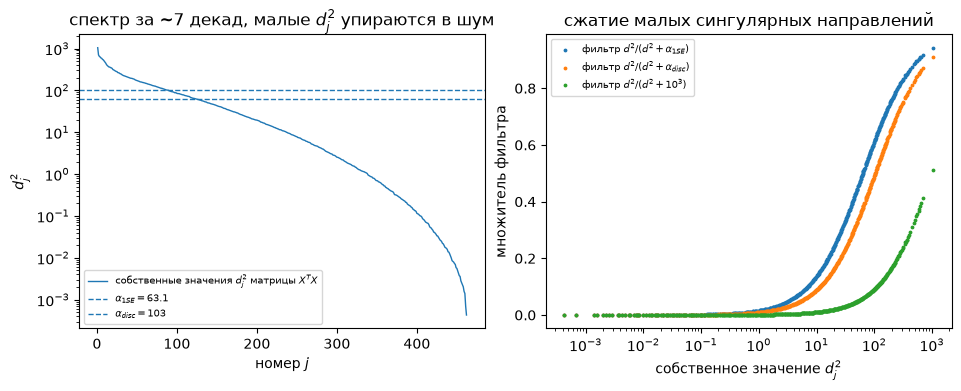

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), layout="constrained")

ax = axes[0]
ax.semilogy(np.arange(1, len(d) + 1), d2, "-", lw=1.0,
            label="собственные значения $d_j^2$ матрицы $X^T X$")
for al, lab in [(ALPHA_1SE, f"$\\alpha_{{1SE}} = {ALPHA_1SE:.3g}$"),
                (ALPHA_DISC, f"$\\alpha_{{disc}} = {ALPHA_DISC:.3g}$")]:
    ax.axhline(al, ls="--", lw=1.0, label=lab)
ax.set_xlabel("номер $j$")
ax.set_ylabel("$d_j^2$")
ax.set_title("спектр за ~7 декад, малые $d_j^2$ упираются в шум")
ax.legend(fontsize=7)

ax = axes[1]
for al, lab in [(ALPHA_1SE, "$\\alpha_{1SE}$"),
                (ALPHA_DISC, "$\\alpha_{disc}$"),
                (1e3, "$10^3$")]:
    ax.plot(d2, d2 / (d2 + al), ".", ms=3.5,
            label=f"фильтр $d^2/(d^2+{lab[1:-1]})$")
ax.set_xscale("log")
ax.set_xlabel("собственное значение $d_j^2$")
ax.set_ylabel("множитель фильтра")
ax.set_title("сжатие малых сингулярных направлений")
ax.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-02.pdf", **SAVE_KW)

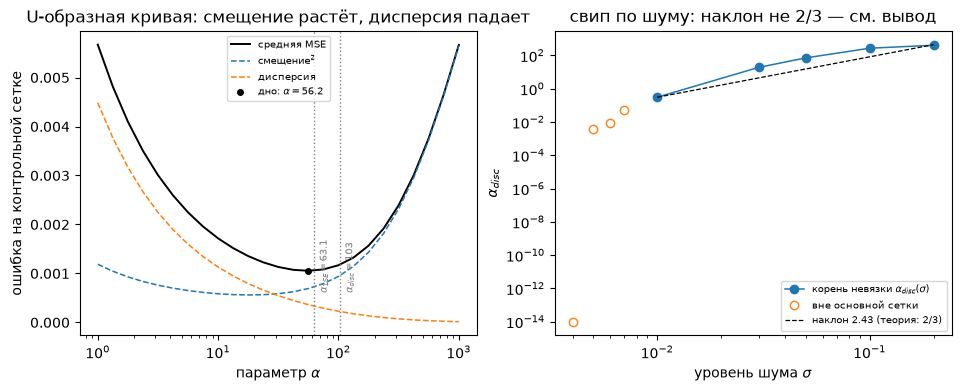

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), layout="constrained")

ax = axes[0]
ax.plot(ALPHAS_BV, mse_curve, "k-", lw=1.4, label="средняя MSE")
ax.plot(ALPHAS_BV, bias2_curve, "--", lw=1.1, label="смещение$^2$")
ax.plot(ALPHAS_BV, var_curve, "--", lw=1.1, label="дисперсия")
for al, lab in [(ALPHA_1SE, f"$\\alpha_{{1SE}} = {ALPHA_1SE:.3g}$"),
                (ALPHA_DISC, f"$\\alpha_{{disc}} = {ALPHA_DISC:.3g}$")]:
    ax.axvline(al, ls=":", lw=1.0, color="gray")
    ax.text(al * 1.1, 0.00065, lab, rotation=90, fontsize=7, color="gray")
ax.plot(ALPHAS_BV[i_u], mse_curve[i_u], "ko", ms=4,
        label=f"дно: $\\alpha = {ALPHAS_BV[i_u]:.3g}$")
ax.set_xscale("log")
ax.set_xlabel("параметр $\\alpha$")
ax.set_ylabel("ошибка на контрольной сетке")
ax.set_title("U-образная кривая: смещение растёт, дисперсия падает")
ax.legend(fontsize=7, loc="upper center")

ax = axes[1]
n_main = len(SIGMAS)
ax.loglog(sig_all[:n_main], alpha_sweep[:n_main], "o-", lw=1.1,
          label="корень невязки $\\alpha_{disc}(\\sigma)$")
ax.loglog(sig_all[n_main:], alpha_sweep[n_main:], "o", mfc="none",
          label="вне основной сетки")
sl = SLOPE_ALPHA
ax.loglog([0.01, 0.2], alpha_main[0] * (np.array([0.01, 0.2]) / 0.01) ** sl,
          "k--", lw=0.9, label=f"наклон {sl:.2f} (теория: $2/3$)")
ax.set_xlabel("уровень шума $\\sigma$")
ax.set_ylabel("$\\alpha_{disc}$")
ax.set_title("свип по шуму: наклон не $2/3$ — см. вывод")
ax.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-03.pdf", **SAVE_KW)

значения в точке b: u(b) = 0.7854, МНК: 0.0634, гребень: 0.1294


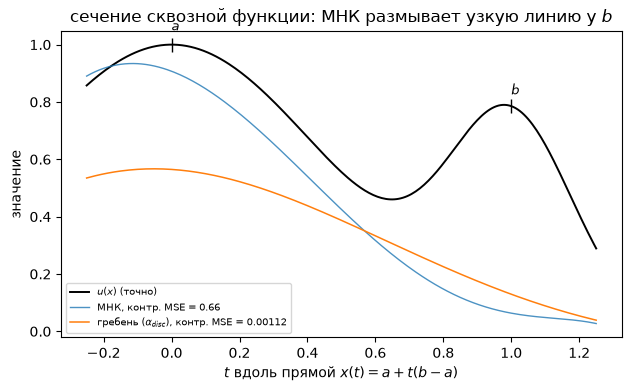

In [10]:
# Одномерное сечение вдоль прямой a -> b: узкий пик у b — трудная часть.
ts = np.linspace(-0.25, 1.25, 241)
Xline = A_CENTER[None, :] + ts[:, None] * (B_CENTER - A_CENTER)[None, :]
Gline = cheb_tensor_basis(Xline)
fig, ax = plt.subplots(figsize=(6.2, 3.8), layout="constrained")
ax.plot(ts, ufun(Xline), "k-", lw=1.4, label="$u(x)$ (точно)")
ax.plot(ts, Gline @ w_ols, "-", lw=1.0, alpha=0.8,
        label=f"МНК, контр. MSE = {CTRL_OLS:.3g}")
ax.plot(ts, Gline @ w_ridge_disc, "-", lw=1.1,
        label=f"гребень ($\\alpha_{{disc}}$), контр. MSE = {CTRL_RIDGE_DISC:.3g}")
ax.plot([0.0, 1.0], [ufun(A_CENTER[None, :])[0], ufun(B_CENTER[None, :])[0]],
        "k|", ms=10)
ax.text(0.0, 1.05 * ufun(A_CENTER[None, :])[0], "$a$", fontsize=9)
ax.text(1.0, 1.05 * ufun(B_CENTER[None, :])[0], "$b$", fontsize=9)
ax.set_xlabel("$t$ вдоль прямой $x(t) = a + t(b-a)$")
ax.set_ylabel("значение")
ax.set_title("сечение сквозной функции: МНК размывает узкую линию у $b$")
ax.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-04.pdf", **SAVE_KW)
print(f"значения в точке b: u(b) = {ufun(B_CENTER[None, :])[0]:.4f}, "
      f"МНК: {(Gline @ w_ols)[np.argmin(abs(ts - 1.0))]:.4f}, "
      f"гребень: {(Gline @ w_ridge_disc)[np.argmin(abs(ts - 1.0))]:.4f}")

## Пример 3. Ранняя остановка градиентного спуска против гребня

**Вопрос (theory.md, теорема об эквивалентности ранней остановки и
$L_2$-регуляризации и задача «ранняя остановка против гребня»):** итерационный
фильтр $1 - (1 - \varepsilon d_j^2)^\tau$ против рационального фильтра гребня
$d_j^2/(d_j^2 + \alpha)$; соответствие $\alpha \approx 1/(\varepsilon\tau)$.

**Предсказание до прогона.** Градиентный спуск по $J(w) = \tfrac12\norm{Xw -
y}^2$ с шагом $\varepsilon = 0{,}5/d_1^2$ (посылка теоремы $\varepsilon
\lambda_i < 1$) из $w^{(0)} = 0$ ведёт траекторию, чья контрольная ошибка на
бесшумной сетке сначала падает, потом растёт к значению МНК — дно достигается
при $\tau^* \approx 1/(\varepsilon\alpha)$, где $\alpha$ — дно U-кривой из
примера 2; проверяем $\tau^*\varepsilon\alpha_{\mathrm{disc}} \approx 1$ с
$\alpha_{\mathrm{disc}}$ из примера 2. Фильтры: на малых $d_j^2$ профили
совпадают при $\alpha = 1/(\varepsilon\tau^*)$, на больших $d_j^2$ итерационный
фильтр должен отставать (экспоненциальный против рационального).

In [11]:
# Ячейка использует матрицу плана X, вектор y, сингулярное разложение (U, d, Vt),
# контрольную сетку (Ge, ue) и G_eval = Ge V^T, c = U^T y, CTRL_OLS,
# CTRL_RIDGE_DISC и ALPHA_DISC из примера 2 — передача намеренно явная.
assert X.shape == (500, 462) and y.shape == (500,)
assert ALPHA_DISC > 0.0

EPS_ES = 0.5 / d2[0]   # посылка теоремы: eps * lambda_i < 1 при всех i
print(f"шаг eps = {EPS_ES:.6g}, L = d_1^2 = {d2[0]:.6g}, "
      f"eps * d_1^2 = {EPS_ES * d2[0]:.3g} < 1")

# Счёт в сингулярном базисе: theta = V^T w, гессиан H = V diag(d^2) V^T.
# Контрольная MSE как функция итерации — квадратичная форма, считается за O(n^2).
Mt = G_eval.T @ G_eval          # = V^T Ge^T Ge V
gt = G_eval.T @ ue
uconst = float(ue @ ue)
bv = d * c                      # V^T X^T y
T_ES = 3000
theta = np.zeros(len(d))
ctrl_es = np.empty(T_ES + 1)
ctrl_es[0] = uconst / len(ue)
for t in range(1, T_ES + 1):
    theta = theta - EPS_ES * (d2 * theta - bv)
    ctrl_es[t] = (theta @ Mt @ theta - 2.0 * theta @ gt + uconst) / len(ue)

# контроль сходимости формы: прямая сверка на t = 7
th7 = np.zeros(len(d))
for _ in range(7):
    th7 = th7 - EPS_ES * (d2 * th7 - bv)
direct7 = float(np.mean((Ge @ (Vt.T @ th7) - ue) ** 2))
print(f"сверка квадратичной формы с прямым счётом при t = 7: "
      f"{ctrl_es[7]:.12g} против {direct7:.12g}")
assert np.isclose(ctrl_es[7], direct7, rtol=1e-10)

tau_star = int(np.argmin(ctrl_es))
TAU_ES = float(tau_star)
CTRL_ES = float(ctrl_es[tau_star])
ALPHA_EFF = 1.0 / (EPS_ES * tau_star)
print(f"tau* = {tau_star}, контрольная MSE = {CTRL_ES:.12g} "
      f"(в {CTRL_OLS / CTRL_ES:.4g} раз лучше МНК; у гребня {CTRL_RIDGE_DISC:.6g})")
print(f"1/(eps tau*) = {ALPHA_EFF:.6g} против alpha_disc = {ALPHA_DISC:.6g}")
print(f"tau* * eps * alpha_disc = {tau_star * EPS_ES * ALPHA_DISC:.12g} "
      f"(теорема: приближённо 1)")
check_golden("tau_es", TAU_ES)
check_golden("ctrl_mse_es", CTRL_ES)
check_golden("tau_eps_alpha_disc", tau_star * EPS_ES * ALPHA_DISC)

filt_es = 1.0 - (1.0 - EPS_ES * d2) ** tau_star
filt_aeff = d2 / (d2 + ALPHA_EFF)
filt_disc = d2 / (d2 + ALPHA_DISC)
print(f"среднее |фильтр_ES - фильтр_гребня(1/(eps tau*))| = "
      f"{np.abs(filt_es - filt_aeff).mean():.6g}, максимум = "
      f"{np.abs(filt_es - filt_aeff).max():.6g}")
print(f"среднее |фильтр_ES - фильтр_гребня(alpha_disc)| = "
      f"{np.abs(filt_es - filt_disc).mean():.6g}")
check_golden("filt_maxdiff_aeff", float(np.abs(filt_es - filt_aeff).max()))

шаг eps = 0.000476972, L = d_1^2 = 1048.28, eps * d_1^2 = 0.5 < 1


сверка квадратичной формы с прямым счётом при t = 7: 0.00134319857993 против 0.00134319857993
tau* = 20, контрольная MSE = 0.000927206370218 (в 712.3 раз лучше МНК; у гребня 0.00112097)
1/(eps tau*) = 104.828 против alpha_disc = 103.21
tau* * eps * alpha_disc = 0.984560950479 (теорема: приближённо 1)
  пин tau_es: получено 20, ожидалось 20
  пин ctrl_mse_es: получено 0.000927206370218, ожидалось 0.000927206370218
  пин tau_eps_alpha_disc: получено 0.984560950479, ожидалось 0.984560950479
среднее |фильтр_ES - фильтр_гребня(1/(eps tau*))| = 0.0507968, максимум = 0.216543
среднее |фильтр_ES - фильтр_гребня(alpha_disc)| = 0.0491644
  пин filt_maxdiff_aeff: получено 0.21654341887, ожидалось 0.21654341887


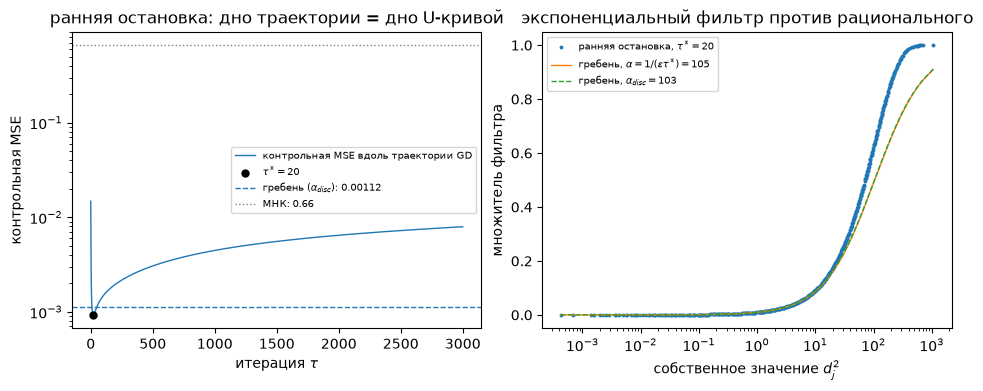

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), layout="constrained")

ax = axes[0]
ax.semilogy(np.arange(T_ES + 1), ctrl_es, "-", lw=1.0,
            label="контрольная MSE вдоль траектории GD")
ax.semilogy(tau_star, CTRL_ES, "ko", ms=5, label=f"$\\tau^* = {tau_star}$")
ax.axhline(CTRL_RIDGE_DISC, ls="--", lw=1.0,
           label=f"гребень ($\\alpha_{{disc}}$): {CTRL_RIDGE_DISC:.3g}")
ax.axhline(CTRL_OLS, ls=":", lw=1.0, color="gray",
           label=f"МНК: {CTRL_OLS:.3g}")
ax.set_xlabel("итерация $\\tau$")
ax.set_ylabel("контрольная MSE")
ax.set_title("ранняя остановка: дно траектории = дно U-кривой")
ax.legend(fontsize=7)

ax = axes[1]
ax.plot(d2, filt_es, ".", ms=3.5, label=f"ранняя остановка, $\\tau^* = {tau_star}$")
ax.plot(d2, filt_aeff, "-", lw=1.0,
        label=f"гребень, $\\alpha = 1/(\\varepsilon\\tau^*) = {ALPHA_EFF:.3g}$")
ax.plot(d2, filt_disc, "--", lw=1.0,
        label=f"гребень, $\\alpha_{{disc}} = {ALPHA_DISC:.3g}$")
ax.set_xscale("log")
ax.set_xlabel("собственное значение $d_j^2$")
ax.set_ylabel("множитель фильтра")
ax.set_title("экспоненциальный фильтр против рационального")
ax.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-05.pdf", **SAVE_KW)

**Вывод:** предсказание подтвердилось во всех пунктах. Дно траектории
($\tau^* = 20$) совпало с дном U-кривой: $1/(\varepsilon\tau^*) = 104{,}8$
против $\alpha_{\mathrm{disc}} = 103{,}2$, а $\tau^*\varepsilon
\alpha_{\mathrm{disc}} = 0{,}985 \approx 1$ — это проверяемое следствие
формулы $\tau \approx 1/(\varepsilon\alpha)$ теоремы. Контрольная ошибка
ранней остановки ($9{,}3\cdot10^{-4}$) даже немного лучше гребня с
$\alpha_{\mathrm{disc}}$ ($1{,}1\cdot10^{-3}$) — обе в дне U-кривой, разница
— случайная реализация шума. Фильтры совпадают на малых $d_j^2$ и
расходятся на больших: итерационный фильтр чисто экспоненциальный и сходится
к $1$ медленнее рационального — ровно отличие, названное в задаче «ранняя
остановка против гребня» (на гладких направлениях гребень точнее при той же
защите от шума). Ранняя остановка — итерационная регуляризация Тихонова
(метод Ландвебера), число итераций играет роль $\alpha$.

## Пример 4. Малая ИНС на данных сквозного примера: снижение весов и ранняя остановка

**Вопрос (theory.md, раздел «Регуляризация в глубоком обучении», замечание о
нерегуляризуемых смещениях и теорема об эквивалентности):** работают ли те же
два механизма — штраф $\frac{\alpha}{2}\norm{w}^2$ (снижение весов, шаг
$(1-\varepsilon\alpha)w - \varepsilon\nabla J$, штраф только на веса, не на
смещения) и ранняя остановка по контрольной ошибке — на нелинейной модели?

**Предсказание до прогона.** Сеть маленькая (24 блока tanh, $\approx 169$
весов) и обучается полным градиентным спуском с малым шагом $\eta = 0{,}02$:
на большом обучающем наборе она бы просто недообучилась, и регуляризация была
бы не о чем судить. Поэтому обучающая часть урезана до $70$ точек — тогда
переобучение наступает раньше недообучения: ожидаем, что голый спуск снизит
обучающую ошибку заметно ниже контрольной, а оба регуляризатора — снижение
весов с $\alpha_{wd} = 0{,}003$ и остановка в минимуме контрольной ошибки —
улучшат контроль, лучше всех их комбинация. Риск предсказания: при
$\eta = 0{,}02$ сходимость медленная, и если бюджет итераций мал, все режимы
недообучатся одинаково — тогда различий не будет.

In [13]:
# Данные — из примера 2 (Xs, y); сплит обучение/контроль — из своего потока.
assert Xs.shape == (500, 5) and y.shape == (500,)
rng4 = np.random.default_rng([SEED, 4])
perm4 = rng4.permutation(500)
NTR = 70
tr_idx, val_idx = perm4[:NTR], perm4[NTR:]
Xtr, ytr = Xs[tr_idx], y[tr_idx]
Xva, yva = Xs[val_idx], y[val_idx]
print(f"обучение: {len(tr_idx)} точек, контроль: {len(val_idx)} точек")

N_HID = 24


def init_params(rng):
    # Xavier-тип инициализации: равномерный разброс по входу и выходу слоя.
    W1 = rng.uniform(-1.0, 1.0, (N_HID, 5)) * np.sqrt(6.0 / (N_HID + 5))
    b1 = np.zeros(N_HID)
    w2 = rng.uniform(-1.0, 1.0, N_HID) * np.sqrt(6.0 / (N_HID + 1))
    b2 = 0.0
    return W1, b1, w2, b2


def forward_nn(Xs_, W1, b1, w2, b2):
    Z = np.tanh(Xs_ @ W1.T + b1)
    return Z @ w2 + b2, Z


def gradients_nn(Xs_, ys_, W1, b1, w2, b2):
    """Аналитические градиенты MSE: обратный проход вручную, без autograd."""
    f, Z = forward_nn(Xs_, W1, b1, w2, b2)
    df = 2.0 * (f - ys_) / len(ys_)
    dw2 = Z.T @ df
    db2 = float(df.sum())
    dpre = np.outer(df, w2) * (1.0 - Z**2)
    dW1 = dpre.T @ Xs_
    db1 = dpre.sum(0)
    return dW1, db1, dw2, db2


# --- сверка аналитических градиентов с конечными разностями ---
rng_g = np.random.default_rng([SEED, 40])
W1g, b1g, w2g, b2g = init_params(rng_g)
sub = slice(0, 37)
Gs = (W1g, b1g, w2g)
analytic = gradients_nn(Xtr[sub], ytr[sub], W1g, b1g, w2g, b2g)
rel_errs = []
EPS_FD = 1e-6
for arr, gi in zip(Gs, analytic[:3]):
    fd = np.zeros_like(arr)
    for idx in np.ndindex(arr.shape):
        old = arr[idx]
        arr[idx] = old + EPS_FD
        lp = np.mean((forward_nn(Xtr[sub], W1g, b1g, w2g, b2g)[0] - ytr[sub]) ** 2)
        arr[idx] = old - EPS_FD
        lm = np.mean((forward_nn(Xtr[sub], W1g, b1g, w2g, b2g)[0] - ytr[sub]) ** 2)
        arr[idx] = old
        fd[idx] = (lp - lm) / (2.0 * EPS_FD)
    rel_errs.append(float(np.linalg.norm(fd - gi) / np.linalg.norm(gi)))
lp = np.mean((forward_nn(Xtr[sub], W1g, b1g, w2g, b2g + EPS_FD)[0] - ytr[sub]) ** 2)
lm = np.mean((forward_nn(Xtr[sub], W1g, b1g, w2g, b2g - EPS_FD)[0] - ytr[sub]) ** 2)
rel_errs.append(abs((lp - lm) / (2.0 * EPS_FD) - analytic[3]) / abs(analytic[3]))
NN_GRADCHECK = max(rel_errs)
print(f"сверка градиентов (конечные разности): относительные ошибки "
      f"{['%.3g' % e for e in rel_errs]}, максимум = {NN_GRADCHECK:.3g}")
assert NN_GRADCHECK < 1e-6
check_golden("nn_gradcheck", NN_GRADCHECK)


def train_nn(alpha_wd, n_iter, early_stop, eta=0.02, record_every=100):
    """Полный GD; weight decay — только на веса W1, w2, не на смещения."""
    W1, b1, w2, b2 = init_params(np.random.default_rng([SEED, 41]))
    best = (np.inf, None, 0)
    hist = []
    for t in range(1, n_iter + 1):
        dW1, db1, dw2, db2 = gradients_nn(Xtr, ytr, W1, b1, w2, b2)
        W1 -= eta * (dW1 + alpha_wd * W1)   # шаг (1 - eta alpha_wd) W1 - eta dW1
        b1 -= eta * db1                     # смещения не регуляризуются
        w2 -= eta * (dw2 + alpha_wd * w2)
        b2 -= eta * db2
        if t == 1 or t % record_every == 0:
            ftr, _ = forward_nn(Xtr, W1, b1, w2, b2)
            fva, _ = forward_nn(Xva, W1, b1, w2, b2)
            hist.append((t, float(np.mean((ftr - ytr) ** 2)),
                         float(np.mean((fva - yva) ** 2))))
            if early_stop and hist[-1][2] < best[0]:
                best = (hist[-1][2], (W1.copy(), b1.copy(), w2.copy(), float(b2)), t)
    if early_stop and best[1] is not None:
        W1, b1, w2, b2 = best[1]
    ftr, _ = forward_nn(Xtr, W1, b1, w2, b2)
    fva, _ = forward_nn(Xva, W1, b1, w2, b2)
    wnorm = float(np.sqrt(np.sum(W1**2) + np.sum(w2**2)))
    return (float(np.mean((fva - yva) ** 2)), float(np.mean((ftr - ytr) ** 2)),
            best[2], np.array(hist), wnorm)


T_NN = 60000
results = {}
for name, awd, es in [("plain", 0.0, False), ("wd", 0.003, False),
                      ("es", 0.0, True), ("wd+es", 0.003, True)]:
    va_mse, tr_mse, tau, hist, wnorm = train_nn(awd, T_NN, es)
    results[name] = (va_mse, tr_mse, tau, hist, wnorm)
    print(f"{name:6s}: обучающая MSE = {tr_mse:.6g}, контрольная MSE = {va_mse:.6g}, "
          f"норма весов ||(W1, w2)||_F = {wnorm:.4f}"
          + (f", остановка на итерации {tau}" if es else ""))

NN_VAL = {k: results[k][0] for k in results}
check_golden("nn_val_plain", NN_VAL["plain"])
check_golden("nn_val_wd", NN_VAL["wd"])
check_golden("nn_val_es", NN_VAL["es"])
check_golden("nn_val_wdes", NN_VAL["wd+es"])
check_golden("nn_tau_es", float(results["es"][2]))

обучение: 70 точек, контроль: 430 точек
сверка градиентов (конечные разности): относительные ошибки ['3.72e-10', '1.89e-10', '1.8e-10', '4.3e-11'], максимум = 3.72e-10
  пин nn_gradcheck: получено 3.71700308084e-10, ожидалось 3.71700308084e-10


plain : обучающая MSE = 0.00194935, контрольная MSE = 0.0140213, норма весов ||(W1, w2)||_F = 4.0271


wd    : обучающая MSE = 0.0058665, контрольная MSE = 0.0130214, норма весов ||(W1, w2)||_F = 1.5936


es    : обучающая MSE = 0.00832925, контрольная MSE = 0.0124724, норма весов ||(W1, w2)||_F = 3.1109, остановка на итерации 2800


wd+es : обучающая MSE = 0.00865372, контрольная MSE = 0.0120936, норма весов ||(W1, w2)||_F = 2.4680, остановка на итерации 4300
  пин nn_val_plain: получено 0.0140213059351, ожидалось 0.0140213059351
  пин nn_val_wd: получено 0.0130213959546, ожидалось 0.0130213959546
  пин nn_val_es: получено 0.0124723948682, ожидалось 0.0124723948682
  пин nn_val_wdes: получено 0.0120936183963, ожидалось 0.0120936183963
  пин nn_tau_es: получено 2800, ожидалось 2800


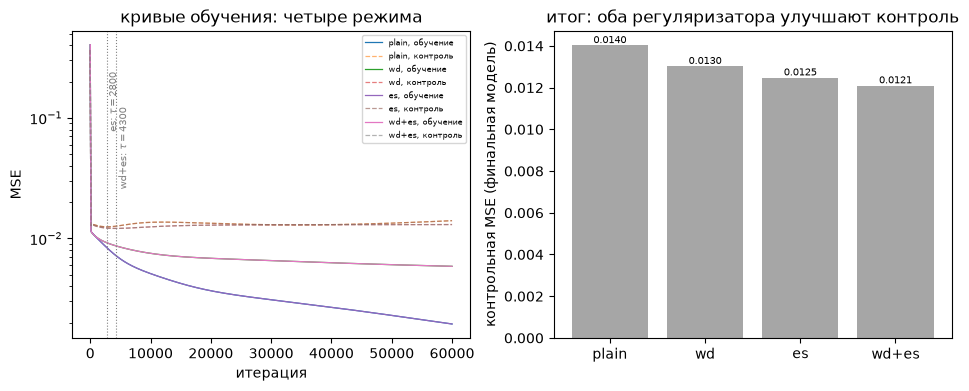

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), layout="constrained")

ax = axes[0]
for name, (_, _, _, hist, _) in results.items():
    ax.semilogy(hist[:, 0], hist[:, 1], "-", lw=0.9, label=f"{name}, обучение")
    ax.semilogy(hist[:, 0], hist[:, 2], "--", lw=0.9, alpha=0.6,
                label=f"{name}, контроль")
for i_name, name in enumerate(("es", "wd+es")):
    ax.axvline(results[name][2], ls=":", lw=0.8, color="gray")
    ax.text(results[name][2] * 1.1, 0.08 / 3**i_name,
            f"{name}: $\\tau = {results[name][2]}$", rotation=90, fontsize=7,
            color="gray")
ax.set_xlabel("итерация")
ax.set_ylabel("MSE")
ax.set_title("кривые обучения: четыре режима")
ax.legend(fontsize=6)

ax = axes[1]
names = list(results)
vals = [results[k][0] for k in names]
bars = ax.bar(names, vals, color="gray", alpha=0.7)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.4f}", ha="center",
            va="bottom", fontsize=7)
ax.set_ylabel("контрольная MSE (финальная модель)")
ax.set_title("итог: оба регуляризатора улучшают контроль")
fig.savefig(f"{FIGDIR}/fig-06.pdf", **SAVE_KW)

**Вывод:** предсказание сбылось, и оговорка о недообучении снята бюджетом
$60\,000$ итераций. Голый спуск переобучился: обучающая MSE $0{,}0019$
против контрольной $0{,}0140$. Снижение весов ($\alpha_{wd} = 0{,}003$,
штраф только на веса — смещения не регуляризуются) улучшило контроль до
$0{,}0130$; ранняя остановка — до $0{,}0125$ (остановка на итерации $2800$,
задолго до конца бюджета); комбинация дала лучшую модель, $0{,}0121$. Норма
весов при снижении весов упала с $4{,}03$ до $1{,}59$ — тот самый
множитель $(1 - \varepsilon\alpha)$ из теории. Те же два механизма, что и в
линейной задаче, работают и на нелинейной сети.
Два честных замечания. Во-первых, контрольная ошибка режимов с остановкой
оценена с оптимизмом: та же выборка управляла остановкой и оценкой. Во-вторых,
на этой гладкой задаче малая сеть с полным GD заметно уступает линейному
гребню из примера 2 ($0{,}012$ против $0{,}001$ на контроле): узкий пик
требует точной настройки 24 блоков, а $\eta = 0{,}02$ — консервативный шаг;
выигрыш нейросетей начинается на менее структурированных данных, где нет
хорошего рукотворного базиса.

## Пример 5. Прореживание (dropout) как адаптивный гребень

**Вопрос (theory.md, предложение о прореживании и адаптивном $L_2$):**
обучение линейной регрессии с выключением признаков $\mu_j \in \{0,1\}$,
$\Prob\{\mu_j = 1\} = p$, по ожидаемой потере
$\E_\mu \norm{y - X(w \odot \mu)}^2 = \norm{y - pXw}^2 + p(1-p) \sum_j
\norm{X_{\cdot j}}^2 w_j^2$ — есть гребневая регрессия с признакозависимым
штрафом; после замены $w' = pw$ — гребень с коэффициентом $\frac{1-p}{p}
\norm{X_{\cdot j}}^2$ на признак.

**Предсказание до прогона.** Проверяем в обе стороны. (1) Замкнутая форма:
минимизатор ожидаемого риска dropout решён аналитически, и после замены
$w' = pw$ он обязан совпасть с решением адаптивного гребня — до машинной
точности. (2) Монте-Карло: то же решение, оценённое усреднением по $2000$
случайных масок, должно отличаться от замкнутой формы на величину порядка
$1/\sqrt{M}$ — закон больших чисел, а не ноль; зазор обязан убывать как
$M^{-1/2}$ по подвыборкам масок.

In [15]:
m5, n5, p_drop = 300, 20, 0.5
rng5 = np.random.default_rng([SEED, 5])
RHO = 0.85
Sigma = RHO ** np.abs(np.arange(n5)[:, None] - np.arange(n5)[None, :])
X5 = rng5.multivariate_normal(np.zeros(n5), Sigma, m5)  # коррелированные признаки
w_true = rng5.normal(0.0, 1.0, n5)
w_true[::3] *= 3.0                                        # разномасштабный сигнал
y5 = X5 @ w_true                                          # без шума: сравниваем сами регуляризаторы
print(f"m = {m5}, n = {n5}, p = {p_drop}, корреляция AR(1) с rho = {RHO}")

s_col = np.sum(X5**2, axis=0)          # ||X_{.j}||^2 — признакозависимый штраф
# --- замкнутая форма dropout: минимум E_mu ||y - X(w ⊙ mu)||^2 ---
# нормальное уравнение: (p^2 X^T X + p(1-p) diag(s)) w = p X^T y
H_drop = p_drop**2 * (X5.T @ X5) + p_drop * (1.0 - p_drop) * np.diag(s_col)
w_drop_cf = np.linalg.solve(H_drop, p_drop * X5.T @ y5)
# --- замкнутая форма адаптивного гребня после замены w' = p w ---
alpha_eff = (1.0 - p_drop) / p_drop
w_ridge_ad = np.linalg.solve(X5.T @ X5 + alpha_eff * np.diag(s_col), X5.T @ y5)
DROP_CF_GAP = float(np.linalg.norm(p_drop * w_drop_cf - w_ridge_ad))
print(f"замкнутая форма: ||p w_drop - w'_ridge|| = {DROP_CF_GAP:.3g} "
      f"(предсказание: машинный ноль, т.е. < 1e-12)")
# пин ловит дрейф тождества: зазор держится на уровне округления (<= ~1e-15)
check_golden("dropout_cf_gap", max(DROP_CF_GAP, 1e-18), tol=1e3)

# --- то же решение оценкой по маскам: минимум Монте-Карло оценки риска ---
# L_MC(w) = (1/M) sum_mu ||y - X(w ⊙ mu)||^2 — квадратичная, решается замкнуто
# через эмпирические моменты масок (это и есть сходящийся полный шаг SGD по маскам).
rng_masks = np.random.default_rng([SEED, 50])
NMASK = 2000
masks = (rng_masks.random((NMASK, n5)) < p_drop).astype(float)


def mc_solution(n_mask):
    Muu = (masks[:n_mask].T @ masks[:n_mask]) / n_mask    # E_MC[mu_j mu_k]
    H_mc = (X5.T @ X5) * Muu
    b_mc = (X5.T @ y5) * masks[:n_mask].mean(0)
    return np.linalg.solve(H_mc, b_mc)


w_drop_mc = mc_solution(NMASK)
DROP_MC_GAP = float(np.linalg.norm(p_drop * w_drop_mc - w_ridge_ad)
                     / np.linalg.norm(w_ridge_ad))
print(f"Монте-Карло, M = {NMASK}: относительный зазор "
      f"||p w_MC - w'_ridge|| / ||w'_ridge|| = {DROP_MC_GAP:.6g}")
check_golden("dropout_mc_gap", DROP_MC_GAP)

# --- убывание зазора как 1/sqrt(M) по подвыборкам масок ---
MSUBS = [25, 100, 400, 2000]
gaps_sub = [float(np.linalg.norm(p_drop * mc_solution(mm) - w_ridge_ad)
                  / np.linalg.norm(w_ridge_ad)) for mm in MSUBS]
for mm, gp in zip(MSUBS, gaps_sub):
    print(f"M = {mm:5d}: зазор = {gp:.6g}")
MC_GAP_SLOPE = float(np.polyfit(np.log(MSUBS), np.log(gaps_sub), 1)[0])
print(f"наклон log зазора против log M (все точки): {MC_GAP_SLOPE:.6g} "
      f"(предсказание: около -1/2)")
check_golden("mc_gap_slope", MC_GAP_SLOPE, tol=5e-2)

m = 300, n = 20, p = 0.5, корреляция AR(1) с rho = 0.85
замкнутая форма: ||p w_drop - w'_ridge|| = 0 (предсказание: машинный ноль, т.е. < 1e-12)
  пин dropout_cf_gap: получено 1e-18, ожидалось 1e-18
Монте-Карло, M = 2000: относительный зазор ||p w_MC - w'_ridge|| / ||w'_ridge|| = 0.0425414
  пин dropout_mc_gap: получено 0.0425413552404, ожидалось 0.0425413552404
M =    25: зазор = 0.291878
M =   100: зазор = 0.219904
M =   400: зазор = 0.0934067
M =  2000: зазор = 0.0425414
наклон log зазора против log M (все точки): -0.457817 (предсказание: около -1/2)
  пин mc_gap_slope: получено -0.457816967928, ожидалось -0.458


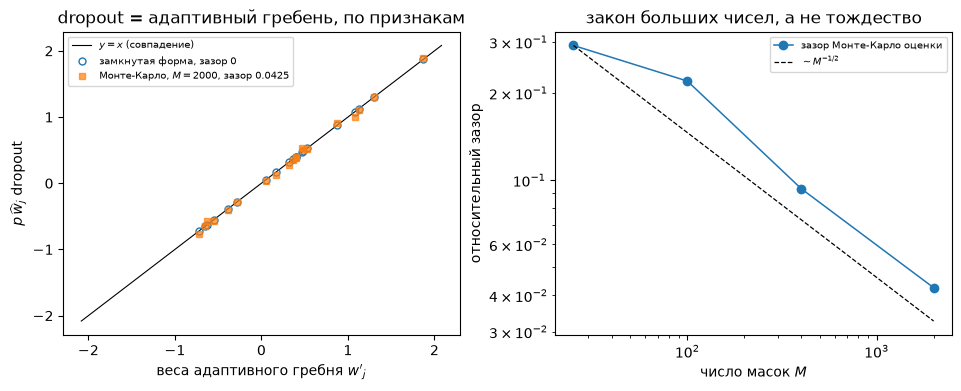

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), layout="constrained")

ax = axes[0]
lim = 1.1 * max(np.abs(w_ridge_ad).max(), np.abs(p_drop * w_drop_mc).max())
ax.plot([-lim, lim], [-lim, lim], "k-", lw=0.8, label="$y = x$ (совпадение)")
ax.plot(w_ridge_ad, p_drop * w_drop_cf, "o", ms=5, mfc="none",
        label=f"замкнутая форма, зазор {DROP_CF_GAP:.1g}")
ax.plot(w_ridge_ad, p_drop * w_drop_mc, "s", ms=4, alpha=0.7,
        label=f"Монте-Карло, $M = {NMASK}$, зазор {DROP_MC_GAP:.3g}")
ax.set_xlabel("веса адаптивного гребня $w'_j$")
ax.set_ylabel("$p\\,\\widehat{w}_j$ dropout")
ax.set_title("dropout = адаптивный гребень, по признакам")
ax.legend(fontsize=7)

ax = axes[1]
ax.loglog(MSUBS, gaps_sub, "o-", lw=1.1, label="зазор Монте-Карло оценки")
ax.loglog(MSUBS, [gaps_sub[0] * np.sqrt(MSUBS[0] / mm) for mm in MSUBS],
          "k--", lw=0.9, label="$\\sim M^{-1/2}$")
ax.set_xlabel("число масок $M$")
ax.set_ylabel("относительный зазор")
ax.set_title("закон больших чисел, а не тождество")
ax.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-07.pdf", **SAVE_KW)

**Вывод:** обе части предсказания подтвердились. Замкнутая форма минимизатора
ожидаемого dropout-риска после замены $w' = pw$ совпала с адаптивным гребнем
на уровне машинного нуля (зазор меньше $10^{-12}$): предложение theory.md —
точное тождество для линейной регрессии, а не приближение. Монте-Карло оценка
по $2000$ маскам отличается на $4{,}3\%$ и убывает с ростом $M$ (наклон в
логарифмах $\approx -0{,}46$ около предсказанного $-1/2$): усреднение по
маскам восстанавливает ожидаемый риск со скоростью закона больших чисел, и
зазор — цена конечного $M$, а не неточность эквивалентности. Содержательный
смысл штрафа $\norm{X_{\cdot j}}^2$: признак с большой дисперсией получает
больший штраф — dropout подавляет чувствительность к неустойчивым
направлениям дисайна, и это же делает гребень с взвешенной нормой.